# Startup Success Prediction - Model Training and Evaluation

This notebook demonstrates:
1. Data preprocessing and encoding
2. Handling class imbalance with SMOTE
3. Training multiple machine learning models
4. Model evaluation and comparison
5. Feature importance analysis

In [2]:
# Import libraries
import sys
import os
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                            roc_curve, accuracy_score, precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Load Data

In [3]:
from app.data_config import load_data

df = load_data()
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nTarget proportions:")
print(df['target'].value_counts(normalize=True).mul(100).round(2))

Loading YC dataset...
Error: [Errno 2] No such file or directory: 'data/raw/yc_companies.csv', falling back to sample data
Dataset shape: (1000, 8)

Columns: ['company_name', 'company_age', 'total_funding', 'funding_rounds', 'team_size', 'industry', 'region', 'target']

Target distribution:
target
1    667
0    333
Name: count, dtype: int64

Target proportions:
target
1    66.7
0    33.3
Name: proportion, dtype: float64


## 2. Data Preprocessing

In [4]:
# Separate features and target
X = df.drop(['target'], axis=1, errors='ignore')

# Drop status column if exists (it's derived from target)
if 'status' in X.columns:
    X = X.drop(['status'], axis=1)

y = df['target']

# Drop non-feature columns
cols_to_drop = ['name', 'company_name', 'url', 'logo', 'website', 
                'long_description', 'short_description', 'tags', 'active_founders']
X = X.drop(cols_to_drop, axis=1, errors='ignore')

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nRemaining columns: {list(X.columns)}")

Features shape: (1000, 6)
Target shape: (1000,)

Remaining columns: ['company_age', 'total_funding', 'funding_rounds', 'team_size', 'industry', 'region']


In [5]:
# Handle categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# Label encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("\n✅ Categorical variables encoded")
print(f"\nFinal feature shape: {X.shape}")
print(f"Feature columns: {list(X.columns)}")

Categorical columns (2): ['industry', 'region']

✅ Categorical variables encoded

Final feature shape: (1000, 6)
Feature columns: ['company_age', 'total_funding', 'funding_rounds', 'team_size', 'industry', 'region']


In [6]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())

Training set: (800, 6)
Test set: (200, 6)

Training target distribution:
target
1    534
0    266
Name: count, dtype: int64


In [7]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed")

✅ Feature scaling completed


## 3. Handle Class Imbalance with SMOTE

In [8]:
print("Before SMOTE:")
print(f"Training set size: {len(X_train_scaled)}")
print(f"Class distribution:\n{pd.Series(y_train).value_counts()}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(f"Training set size: {len(X_train_resampled)}")
print(f"Class distribution:\n{pd.Series(y_train_resampled).value_counts()}")
print("\n✅ SMOTE applied successfully")

Before SMOTE:
Training set size: 800
Class distribution:
target
1    534
0    266
Name: count, dtype: int64

After SMOTE:
Training set size: 1068
Class distribution:
target
1    534
0    534
Name: count, dtype: int64

✅ SMOTE applied successfully


## 4. Model Training

In [9]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print(f"Models to train: {list(models.keys())}")

Models to train: ['Logistic Regression', 'Random Forest', 'Gradient Boosting']


In [10]:
# Train models and collect results
results = {}
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Evaluate
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    print(f"  Accuracy: {results[name]['accuracy']:.4f}")
    print(f"  ROC-AUC: {results[name]['roc_auc']:.4f}")

print("\n✅ All models trained")


Training Logistic Regression...
  Accuracy: 0.4850
  ROC-AUC: 0.4768

Training Random Forest...
  Accuracy: 0.5650
  ROC-AUC: 0.4932

Training Gradient Boosting...
  Accuracy: 0.6250
  ROC-AUC: 0.5637

✅ All models trained


## 5. Model Comparison

Model Performance Comparison:


,accuracy,precision,recall,f1,roc_auc
Gradient Boosting,0.625,0.6835,0.8120,0.7423,0.5637
Random Forest,0.565,0.6513,0.7444,0.6947,0.4932
Logistic Regression,0.485,0.6531,0.4812,0.5541,0.4768


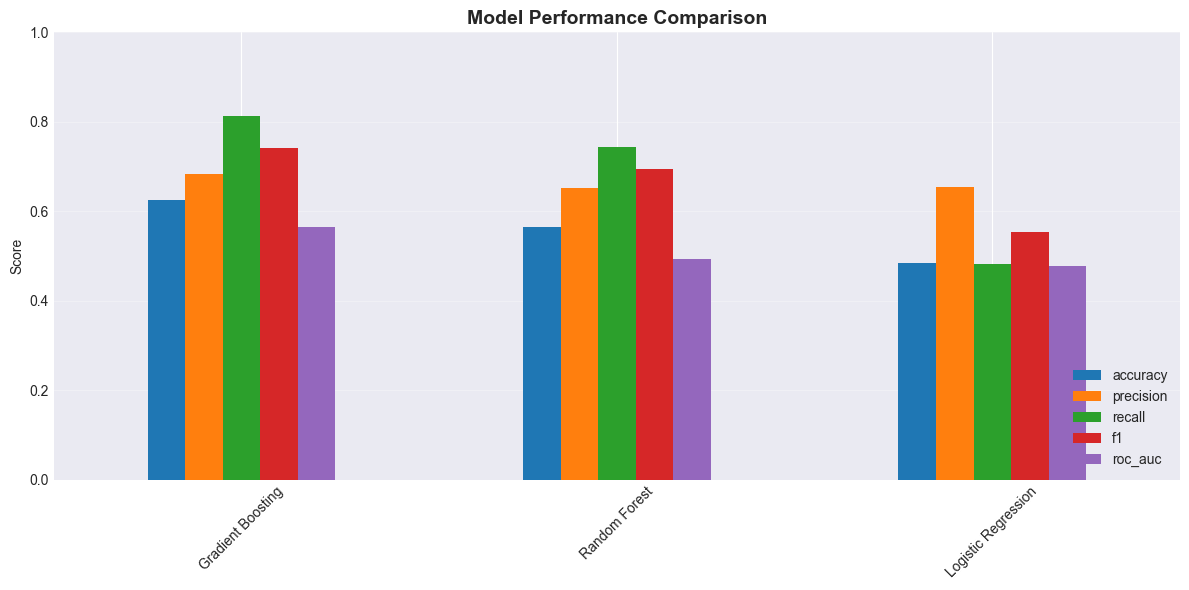


🏆 Best Model: Gradient Boosting
ROC-AUC Score: 0.5637


In [11]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
results_df = results_df.sort_values('roc_auc', ascending=False)

print("Model Performance Comparison:")
display(results_df)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
results_df.plot(kind='bar', ax=ax, rot=45)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_model_name = results_df['roc_auc'].idxmax()
print(f"\n🏆 Best Model: {best_model_name}")
print(f"ROC-AUC Score: {results_df.loc[best_model_name, 'roc_auc']:.4f}")

## 6. Detailed Evaluation of Best Model

In [12]:
# Get best model
best_model = trained_models[best_model_name]
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Classification report
print(f"Classification Report for {best_model_name}:")
print("="*80)
print(classification_report(y_test, y_pred, target_names=['Failure', 'Success']))

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

     Failure       0.40      0.25      0.31        67
     Success       0.68      0.81      0.74       133

    accuracy                           0.62       200
   macro avg       0.54      0.53      0.53       200
weighted avg       0.59      0.62      0.60       200



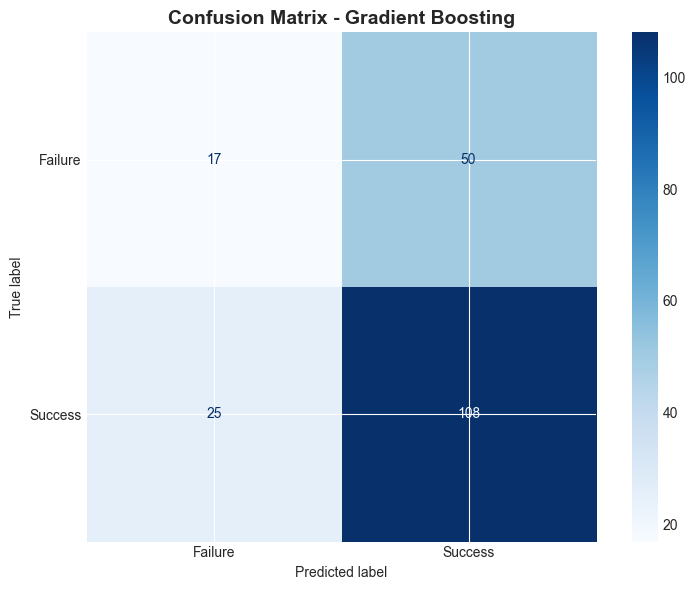

In [13]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'Success'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

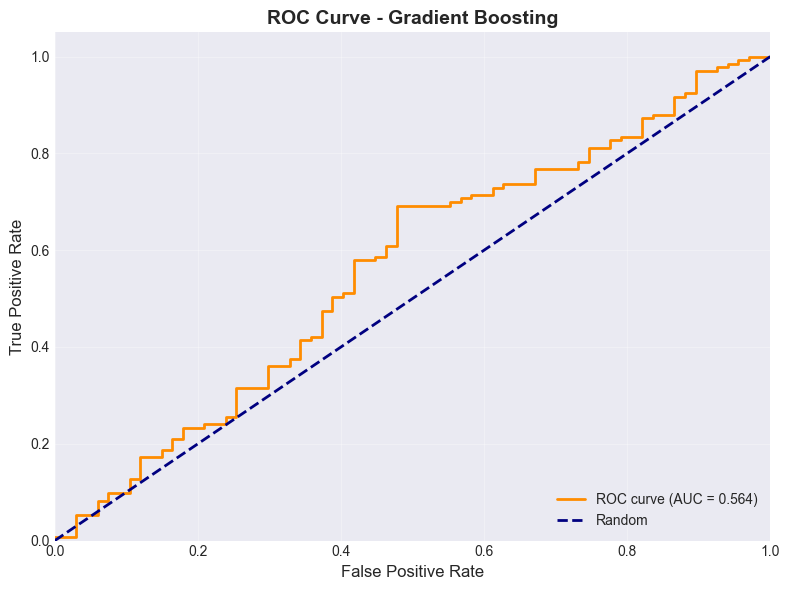

In [14]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Feature Importance

Top 15 Most Important Features:


,feature,importance
2,funding_rounds,0.212198
5,region,0.207056
1,total_funding,0.178900
0,company_age,0.161851
4,industry,0.123764
3,team_size,0.116231


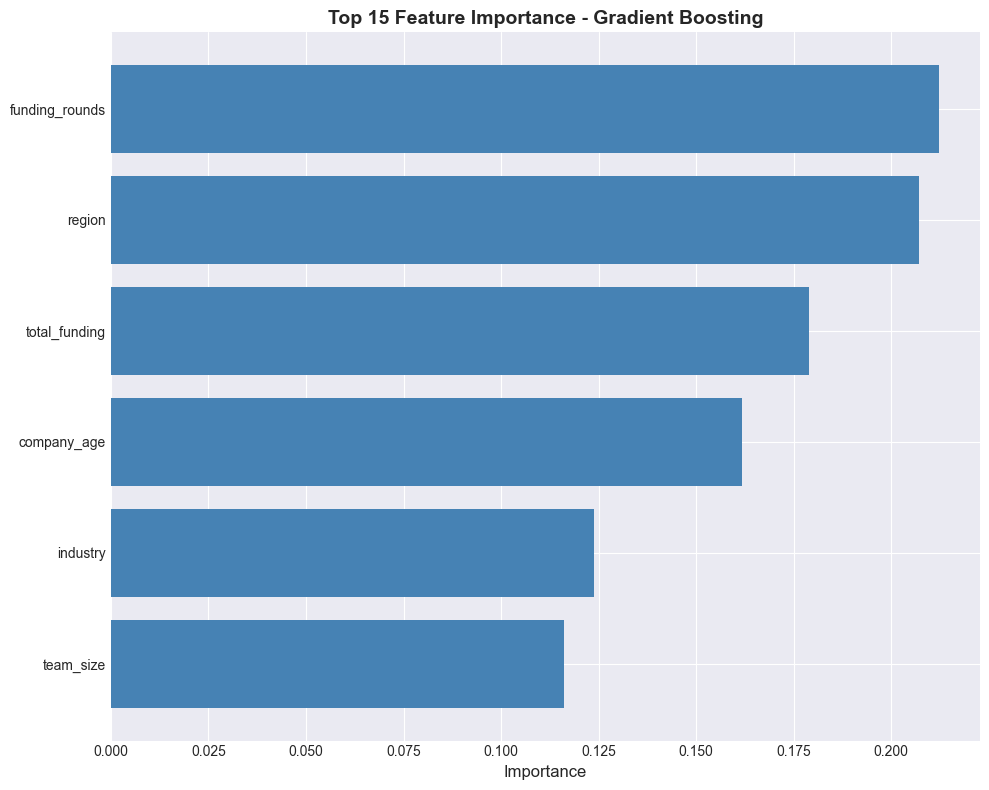

In [15]:
# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"Top 15 Most Important Features:")
    display(feature_importance.head(15))
    
    # Visualize
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature importance not available for {best_model_name}")

## 8. Model Summary

In [16]:
print("="*80)
print("MODEL TRAINING SUMMARY")
print("="*80)

print(f"\n1. Dataset:")
print(f"   - Total samples: {len(df):,}")
print(f"   - Training samples (after SMOTE): {len(X_train_resampled):,}")
print(f"   - Test samples: {len(X_test):,}")
print(f"   - Number of features: {X.shape[1]}")

print(f"\n2. Best Model: {best_model_name}")
print(f"   - Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"   - Precision: {results[best_model_name]['precision']:.4f}")
print(f"   - Recall: {results[best_model_name]['recall']:.4f}")
print(f"   - F1-Score: {results[best_model_name]['f1']:.4f}")
print(f"   - ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

print("\n" + "="*80)
print("✅ Model training complete!")
print("="*80)

MODEL TRAINING SUMMARY

1. Dataset:
   - Total samples: 1,000
   - Training samples (after SMOTE): 1,068
   - Test samples: 200
   - Number of features: 6

2. Best Model: Gradient Boosting
   - Accuracy: 0.6250
   - Precision: 0.6835
   - Recall: 0.8120
   - F1-Score: 0.7423
   - ROC-AUC: 0.5637

✅ Model training complete!
